# Rep 3. Checkpoint 4. Payoff diagrams

* Nicolas Martinez
* Gonzalo Cano

## 1. Obtención de datos reales de SPY

Descargamos el precio actual de SPY y las primas mid del call y put con strike K = 680 y vencimiento 2026-04-17.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'
K   = 680

calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

row_call = calls[calls['strike'] == K].iloc[0]
row_put  = puts[puts['strike'] == K].iloc[0]

C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid']  + row_put['ask'])  / 2

print(f"S0 = {S0:.2f}  |  K = {K}  |  C = {C:.4f}  |  P = {P:.4f}")

S0 = 653.18  |  K = 680  |  C = 3.4100  |  P = 28.4350


## 2. Cálculo de payoffs y P&L neto

In [6]:
# Rango de precios al vencimiento centrado en K
S_range = np.linspace(K - 80, K + 80, 500)

# --- Payoffs brutos ---
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

## 3. Plot 2×2: Las cuatro posiciones básicas

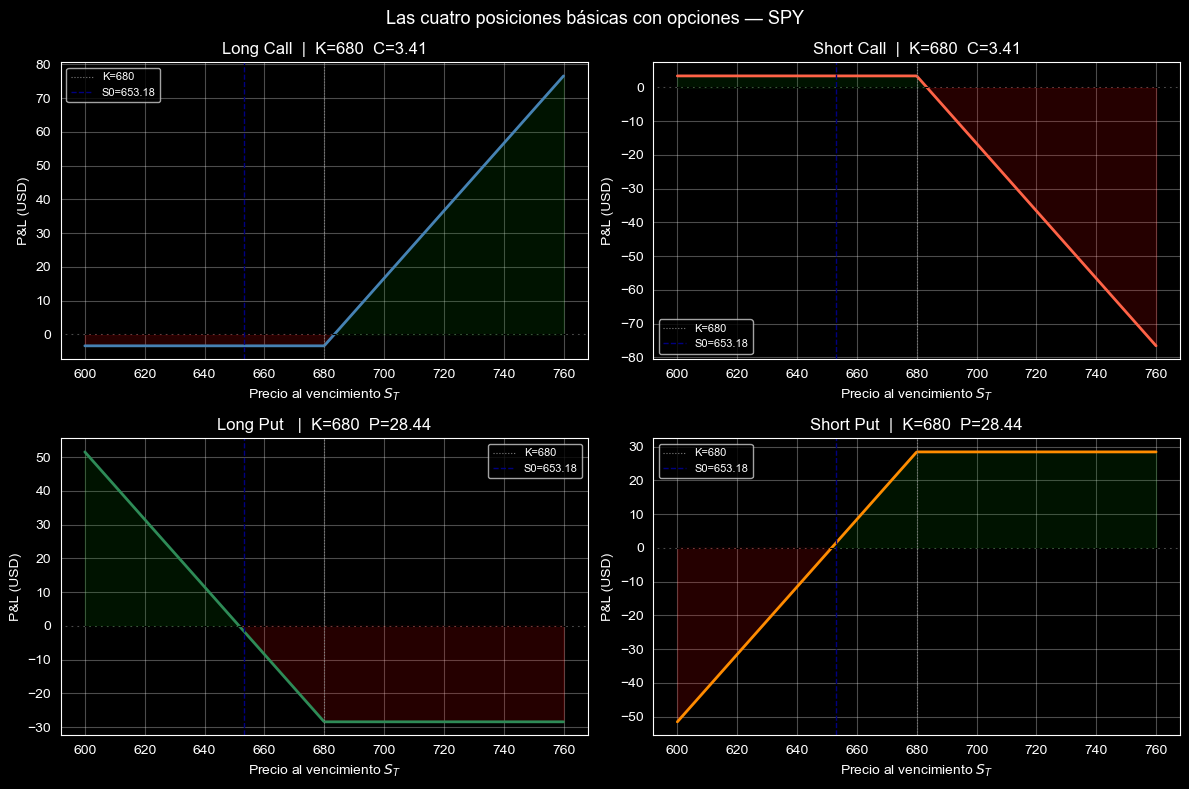

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0, 0], pnl_call_long,  f'Long Call  |  K={K}  C={C:.2f}',  'steelblue'),
    (axes[0, 1], pnl_call_short, f'Short Call  |  K={K}  C={C:.2f}', 'tomato'),
    (axes[1, 0], pnl_put_long,   f'Long Put   |  K={K}  P={P:.2f}',  'seagreen'),
    (axes[1, 1], pnl_put_short,  f'Short Put  |  K={K}  P={P:.2f}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray', linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.axvline(S0, color='navy', linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L (USD)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones — SPY', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Comparación payoff bruto vs. P&L neto (Call y Put)

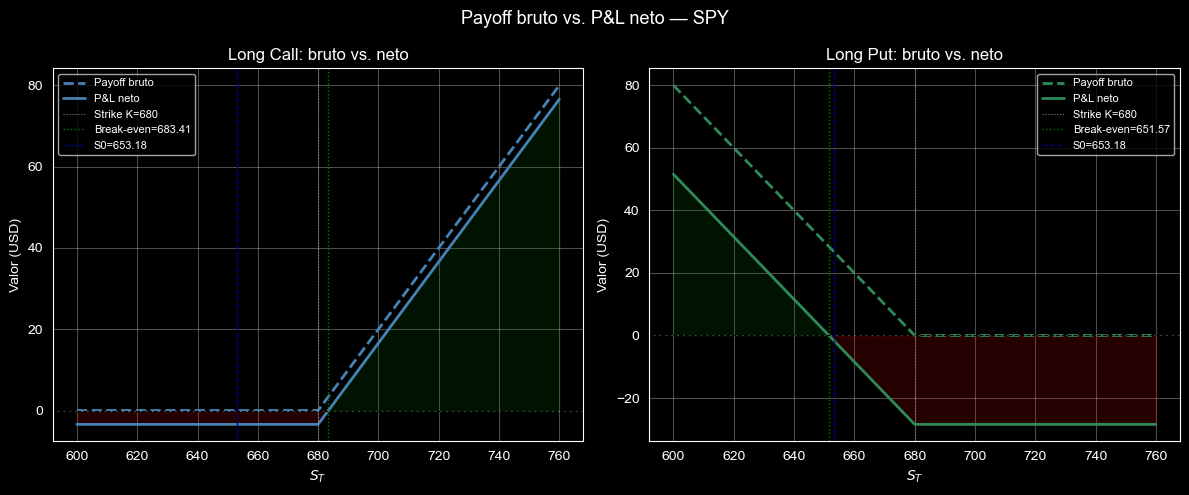

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Long Call: payoff bruto vs P&L neto
axes[0].plot(S_range, call_long_bruto, color='steelblue',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[0].plot(S_range, pnl_call_long, color='steelblue',
             linewidth=2, label='P&L neto')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(K,     color='gray',  linewidth=0.8, linestyle=':', label=f'Strike K={K}')
axes[0].axvline(K + C, color='green', linewidth=1.0, linestyle=':', label=f'Break-even={K+C:.2f}')
axes[0].axvline(S0,    color='navy',  linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
axes[0].fill_between(S_range, pnl_call_long, 0, where=(pnl_call_long > 0), alpha=0.15, color='green')
axes[0].fill_between(S_range, pnl_call_long, 0, where=(pnl_call_long < 0), alpha=0.15, color='red')
axes[0].set_title('Long Call: bruto vs. neto')
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Valor (USD)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Long Put: payoff bruto vs P&L neto
axes[1].plot(S_range, put_long_bruto, color='seagreen',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[1].plot(S_range, pnl_put_long, color='seagreen',
             linewidth=2, label='P&L neto')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(K,     color='gray',  linewidth=0.8, linestyle=':', label=f'Strike K={K}')
axes[1].axvline(K - P, color='green', linewidth=1.0, linestyle=':', label=f'Break-even={K-P:.2f}')
axes[1].axvline(S0,    color='navy',  linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
axes[1].fill_between(S_range, pnl_put_long, 0, where=(pnl_put_long > 0), alpha=0.15, color='green')
axes[1].fill_between(S_range, pnl_put_long, 0, where=(pnl_put_long < 0), alpha=0.15, color='red')
axes[1].set_title('Long Put: bruto vs. neto')
axes[1].set_xlabel('$S_T$')
axes[1].set_ylabel('Valor (USD)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Payoff bruto vs. P&L neto — SPY', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Tabla de break-evens

In [7]:
be_call_long  = K + C
be_call_short = K + C
be_put_long   = K - P
be_put_short  = K - P

distancias = {
    'Long Call':  abs(be_call_long  - S0),
    'Short Call': abs(be_call_short - S0),
    'Long Put':   abs(be_put_long   - S0),
    'Short Put':  abs(be_put_short  - S0),
}

tabla = pd.DataFrame({
    'Posición':        ['Long Call', 'Short Call', 'Long Put', 'Short Put'],
    'Fórmula BE':      ['K + C', 'K + C', 'K - P', 'K - P'],
    'Break-even (USD)': [be_call_long, be_call_short, be_put_long, be_put_short],
    'Distancia a S0':  [distancias['Long Call'], distancias['Short Call'],
                        distancias['Long Put'],  distancias['Short Put']],
})

tabla['Break-even (USD)'] = tabla['Break-even (USD)'].round(2)
tabla['Distancia a S0']   = tabla['Distancia a S0'].round(2)

print(f"S0 actual = {S0:.2f}  |  K = {K}  |  C = {C:.4f}  |  P = {P:.4f}\n")
print(tabla.to_string(index=False))

pos_mas_cercana = min(distancias, key=distancias.get)
print(f"\nPosición con break-even más cercano a S0: {pos_mas_cercana} (distancia = {distancias[pos_mas_cercana]:.2f})")

S0 actual = 653.18  |  K = 680  |  C = 3.4100  |  P = 28.4350

  Posición Fórmula BE  Break-even (USD)  Distancia a S0
 Long Call      K + C            683.41           30.23
Short Call      K + C            683.41           30.23
  Long Put      K - P            651.57            1.61
 Short Put      K - P            651.57            1.61

Posición con break-even más cercano a S0: Long Put (distancia = 1.61)


---
## Preguntas de análisis

### Pregunta 1
**¿Cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?**

Con los datos obtenidos:
- **Long Call / Short Call**: break-even en K + C
- **Long Put / Short Put**: break-even en K − P

Dado que K = 680 está significativamente por encima de S0, ambos break-evens quedan alejados del precio actual. Sin embargo, el break-even de la **Long Put / Short Put** (K − P) es menor que el del Call, por lo que en términos absolutos resulta relativamente más cercano a S0 si este cotiza por debajo de K.

La implicación práctica es que, con el strike OTM, ninguna posición tiene un break-even cómodo respecto al precio actual: el mercado tendría que moverse fuertemente hacia K para que las posiciones empiecen a generar ganancia neta. Esto refleja el costo de la prima y el hecho de operar opciones fuera del dinero.

### Pregunta 2
**Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?**

Cuando $S_T = K$:

| Posición | Payoff bruto | Prima pagada/cobrada | P&L neto |
|---|---|---|---|
| Long Call  | max(K − K, 0) = 0 | −C | **−C** |
| Short Call | −max(K − K, 0) = 0 | +C | **+C** |
| Long Put   | max(K − K, 0) = 0 | −P | **−P** |
| Short Put  | −max(K − K, 0) = 0 | +P | **+P** |

Cuando el precio termina exactamente en el strike, el payoff intrínseco de todas las posiciones es cero. El resultado final queda determinado **únicamente por la prima**: los compradores (long) pierden la prima que pagaron, y los vendedores (short) se quedan con la prima cobrada. Esto ilustra que el riesgo máximo del comprador es la prima y que el precio exacto al strike es el peor escenario posible para recuperar algo el día de vencimiento.

### Pregunta 3
**Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?**

| Posición | Pérdida máxima |
|---|---|
| Long Call | Limitada: **−C** (si $S_T \leq K$, solo se pierde la prima pagada) |
| Short Put | Potencialmente alta: **−(K − P)** cuando $S_T = 0$ (el activo colapsa a cero) |

La **short put tiene considerablemente más riesgo**. El vendedor del put está obligado a comprar el activo al strike K si el comprador ejerce; si SPY cae fuertemente (o en un escenario extremo colapsa), la pérdida puede ser muy grande, acotada solo por el hecho de que el precio no puede ser negativo. En contraste, el comprador del call tiene **riesgo definido y acotado**: lo peor que le puede pasar es perder la prima C que pagó, independientemente de cuánto caiga el mercado.

### Pregunta 4
**¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?**

Ambas posiciones se benefician cuando el mercado cae, pero su perfil de riesgo es radicalmente distinto:

| Criterio | Long Put | Short Call |
|---|---|---|
| Ganancia máxima | Alta (hasta K − P si $S_T → 0$) | Limitada a la prima cobrada C |
| Pérdida máxima | Limitada a la prima pagada P | Ilimitada (si $S_T$ sube sin tope) |
| Capital requerido | Prima pagada | Margen (garantías) |
| Conviene cuando | Caída fuerte o cobertura ante evento de riesgo | Mercado lateral-bajista, volatilidad elevada para cobrar prima grande |

Elegiría una **long put** sobre una short call cuando:
1. **Se espera una caída pronunciada** (no solo lateral): la long put tiene ganancia ilimitada a la baja, mientras que la short call solo retiene la prima.
2. **El objetivo es cobertura (hedging)**: la long put protege un portafolio largo con pérdida conocida de antemano.
3. **El entorno es de alta incertidumbre o eventos de cola** (crisis, resultados, macro): con riesgo de salto brusco al alza, la short call queda expuesta a pérdidas ilimitadas.
4. **No se quiere asumir riesgo de margen**: la long put requiere solo pagar la prima; la short call exige garantías que pueden aumentar si el mercado se mueve en contra.